In [146]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [147]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

import xtrack as xt
import xpart as xp
import xplt


import crystal_extraction.plotters as plotters
import crystal_extraction.utils as utils
from crystal_extraction.xsuite_line_creation import create_xsuite_line
#from crystal_extraction.crystal_extraction import CrystalExtraction
from crystal_extraction.dummy_crystal import DummyCrystal
from crystal_extraction.steinbach import Steinbach, BeamArgs, SteinArgs, sps_crystal

plotters.my_mpl_style()


In [148]:
import pickle
import typing as t

import matplotlib.pyplot as plt
import numpy as np
import requests
import xobjects as xo
import xpart as xp
import xtrack as xt
import xcoll as xc
from cpymad.madx import Madx

%matplotlib widget

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import minimize
import itertools
from shapely.geometry import Polygon
import re
import os
import pickle
from cpymad.madx import Madx
import distutils

import warnings
from IPython.display import display, HTML, Markdown, clear_output

display(HTML("<style>.rendered_html { font-size: 17px; }</style>"))
display(HTML("<style>.container { width:90% !important; }</style>"))

def printmd(string):
    display(Markdown(string))
# warnings.filterwarnings('ignore')



plt.ion()

p = 400.0  # beam momentum (GeV/c)
momentum = p  # beam momentum (GeV/c)
Brho = p * 3.3356  # beam rigidity ???

N_EX = 10e-6
N_EY = 5e-6


In [149]:
# Proton mass in GeV/c^2
proton_mass_GeV = xt.PROTON_MASS_EV * 1e-9

# Beam energy in GeV
beam_energy_GeV = 400

# Compute gamma
gamma = beam_energy_GeV / proton_mass_GeV
print(f"Gamma: {gamma}")

Gamma: 426.3155693395322


In [150]:
EX = N_EX / gamma
EY = N_EY / gamma
print(f"EX: {EX}")

EX: 2.3456802235706435e-08


In [151]:
deltaP_P = 1.5e-3
print(f"deltaP_P: {deltaP_P}")

deltaP_P: 0.0015


In [152]:
from elements import TECA
from elements import TECS


# Given values
x_teca = TECA.jaw  
delta_x_teca_prime = TECA.tilt + TECA.bending_angle 

In [153]:
def match_tunes(line, qx, qy):
    # Extraction tunes
    opt = line.match(solve=False,
                     method='4d',
        vary=[
            xt.VaryList(['kqf', 'kqd'], step=1e-7),   # Varying quadrupole focal strengths
            xt.VaryList(['qph_setvalue', 'qpv_setvalue'], step=1e-4),   # Varying phase values
        ],
        targets=[
            xt.TargetSet(qx=qx, qy=qy, tol=1e-5),# Desired target tunes
            #xt.TargetSet(dqx=-1 * qx, dqy=0.47 * qy, tol=1e-3),   # Desired target chromaticities
        ])
    return opt

In [154]:
def match_chromaticity(line, qx, qy):
    # Extraction tunes
    opt = line.match(solve=False,
                     method='4d',
        vary=[
            xt.VaryList(['klsfa', 'klsda', 'klsdb', 'klsfb'], step=1e-7),   # Varying setupoles strengths ,  klsfa, klsda, klsfb, klsdb????
        ],
        targets=[
            xt.TargetSet(dqx=-1 * int(qx), dqy = 0.47 * int(qy), tol=1e-3),   # Desired target chromaticities
        ])
    return opt

# Importing the line

In [155]:
from elements import install_septa
line = xt.Line.from_json("../database/lhc_q22.json")


# REFERENCE PARTICLE
line.particle_ref = xt.Particles(p0c=400e9, mass0=xt.PROTON_MASS_EV)

# INSERTING MARKERS
line.insert_element(name='zs21633.entry.p1mm', element=xt.Marker(), at_s=line.get_table()['s', 'ap.up.zs21633']+1e-3)
line.insert_element("tpst.21760_entry", xt.Marker(), at_s = 1712.2203)
line.insert_element("TECA.entry", xt.Marker(), at_s = 4020.8939)
#line.insert_element("TECS.everest_crystal", TECS, at_s = line.get_table()['s', 'tecs.21602'] )

line.insert_element("tcsm.51932.", xt.Marker(), at_s = 5219.6766)

teca_entry_s = line.get_table()['s', 'TECA.entry']

line.cycle("TECA.entry", inplace=True)


Loading line from dict:   0%|          | 0/4598 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/4598 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4601 [00:00<?, ?it/s]

<Line  at 5026389200>

In [156]:
tw_init = line.twiss(method='4d')
print(tw_init.qx)
print(tw_init.qy)

tw0 = tw_init.to_pandas()
tw0.index = tw0.name  

betx_teca = tw0.loc['TECA.entry'].betx
dx_teca = tw0.loc['TECA.entry'].dx

# COMPUTING THE BEAM SIZE 
tw0['sx_mm'] = np.sqrt(tw0['betx'] * EX + (tw0['dx'] * deltaP_P)**2) * 1e3
tw0['sy_mm'] = np.sqrt(tw0['bety'] * EY + (tw0['dy'] * deltaP_P)**2) * 1e3
    
B_term0 = betx_teca * EX
D_term0 = (dx_teca * deltaP_P)**2
ratio0 = D_term0 / B_term0

print(f'D term / B term = {ratio0:.2f}')
print(f"sigma_x max = {tw0.sx_mm.max()} mm")
print(f"sigma_y max = {tw0.sy_mm.max()} mm")

# DISPERSION AND BETX AT THE TECA LOCATION
betx_teca = tw0.loc['TECA.entry'].betx
dx_teca = tw0.loc['TECA.entry'].dx

# COMPUTING THE BEAM SIZE 
tw0['sx_mm'] = np.sqrt(tw0['betx'] * EX + (tw0['dx'] * deltaP_P)**2) 
tw0['sy_mm'] = np.sqrt(tw0['bety'] * EY + (tw0['dy'] * deltaP_P)**2)
    
B_term0 = betx_teca * EX
D_term0 = (dx_teca * deltaP_P)**2
ratio0 = D_term0 / B_term0

sigma_xMAXQ22 = tw0.sx_mm.max()
sigma_yMAXQ22 = tw0.sy_mm.max()


print(f'D term / B term = {ratio0:.2f}')
print(f"sigma_x max = {tw0.sx_mm.max()} m")
print(f"sigma_y max = {tw0.sy_mm.max()} m")

mu_x_teca = tw0.loc['TECA.entry'].mux
mu_x_tpst = tw0.loc['tpst.21760_entry'].mux
mu_x_tcsm = tw0.loc['tcsm.51932.'].mux

phaseAdvanceTecaTpst = mu_x_tpst - mu_x_teca
phaseAdvanceTecaTcsm = mu_x_tcsm - mu_x_teca
phaseAdvanceTpstTcsm = mu_x_tcsm - mu_x_tpst

print(f"Phase advance Teca - Tpst: {phaseAdvanceTecaTpst:.2f}")
print(f"Phase advance Teca - Tcsm: {phaseAdvanceTecaTcsm:.2f}")
print(f"Phase advance Tpst - Tcsm: {phaseAdvanceTpstTcsm:.2f}")

22.13000000010263
22.180000000010537
D term / B term = 3.31
sigma_x max = 10.468444863433009 mm
sigma_y max = 1.1036200168346404 mm
D term / B term = 3.31
sigma_x max = 0.010468444863433008 m
sigma_y max = 0.0011036200168346405 m
Phase advance Teca - Tpst: 14.74
Phase advance Teca - Tcsm: 3.83
Phase advance Tpst - Tcsm: -10.91


In [157]:
# Get the positions of the TECA and COLLIMATORS markers
teca_position = line.get_table()['s', 'TECA.entry']
tpst_position = line.get_table()['s', 'tpst.21760_entry']
tcsm_position = line.get_table()['s', 'tcsm.51932.']


# Select the tune

In [158]:
tune = 23.01

In [159]:
optTune = match_tunes(line, tune, tune + 0.05)
optChromaticity = match_chromaticity(line, tune, tune + 0.05)

optTune.step(10)
optTune.target_status()
optTune.vary_status()

# CHanging the chromaticity afterwards
optChromaticity.step(10)

optChromaticity.target_status()
optChromaticity.vary_status() 

# Save the line with the current optics into a JSON file
line.to_json("../database/lhc_q23.json")

line.discard_tracker()


                                             
Optimize - start penalty: 12.45         
Matching: model call n. 13               
Optimize - end penalty:  2.92327e-05
Target status:                           
id state tag tol_met       residue   current_val    target_val description                          
0  ON    qx     True   -2.8053e-06         23.01         23.01 'qx', val=23.01, tol=1e-05, weight=10
1  ON    qy     True   8.22068e-07         23.06         23.06 'qy', val=23.06, tol=1e-05, weight=10
Vary status:                 
id state tag met name         lower_limit   current_val upper_limit val_at_iter_0          step        weight
0  ON        OK  kqf          None                0.013 None            0.0125751         1e-07             1
1  ON        OK  kqd          None           -0.0130029 None           -0.0125777         1e-07             1
2  ON        OK  qph_setvalue None          4.22217e-14 None                    0        0.0001             1
3  ON        OK  qp

Generating the twiss computation

In [160]:
tw = line.twiss(method='4d')

tw_df = tw.to_pandas()
tw_df.set_index('name', inplace=True)
tw_df = tw_df.loc['mdha.21606':'drift_mdva.21932..1'] 
tw_df = tw_df.drop_duplicates(subset='s')



# Find apertures that block the particles and open them

In [161]:
import numpy as np
import xtrack as xt
from elements import install_septa

# Storage for elements blocking the particle
blocking_elements = []

while True:
    # Build tracker
    line.build_tracker()

    # Initialize non-channeled particle at TECA location
    particlesNONCH = line.build_particles(
        method='4d',
        x = TECA.jaw,  # Start with 0 offset
        px = TECA.tilt,  # Start with 0 offset
        y=0.0,
        py=0.0,
        zeta=0.0,
        delta = deltaP_P,
        mass0=xt.PROTON_MASS_EV,
        p0c=400e9
    )

    # Track the particle
    line.track(particlesNONCH, num_turns=1, turn_by_turn_monitor="ONE_TURN_EBE")

    # Check if the particle reached the end
    if particlesNONCH.state[0] >= 1 and particlesNONCH.at_element[0] == line.get_table()['name', '_end_point']:
        print("Particle successfully reached the end.")
        break  # Exit loop

    if np.any(particlesNONCH.state < 1):
        lost_turn = np.where(particlesNONCH.state < 1)[0][0]
        lost_element_index = particlesNONCH.at_element[lost_turn]
        lost_element_name = line.element_names[lost_element_index]
        print(f"Particle lost at element {lost_element_name} (index {lost_element_index}) on turn {lost_turn}")
        
        # Store blocking element details
        blocking_elements.append((lost_element_name, particlesNONCH.x[lost_turn]))
        element = line[lost_element_name]
        if isinstance(element, xt.LimitEllipse):
            print(f"Element Name: {lost_element_name}, Element: {element}")
            element.a *= 1.5  # Increase the semi-major axis by 50%
            element.b *= 1.5  # Increase the semi-minor axis by 50%
        elif hasattr(element, 'min_x') and hasattr(element, 'max_x'):
            print(f"Element Name: {lost_element_name}, Element: {element}")
            element.min_x *= 1.5  # Increase the minimum x aperture by 50%
            element.max_x *= 1.5  # Increase the maximum x aperture by 50%
        else:
            print(f"Element {lost_element_name} does not have adjustable apertures.")
        
        
    else:
        print("Particle not lost during the tracking")
        break
    # line.discard_tracker()
    # Increase aperture of the blocking element
    #if hasattr(line[lost_element_name], 'max_x'):
    #    line[lost_element_name].max_x = abs(x_position_at_loss) + 1e-3  # Slightly increase aperture

# Print results
print("Blocking elements encountered:")
for elem, x_pos in blocking_elements:
    print(f"Element: {elem}, X position: {x_pos}")


The line already has an associated tracker
Particle lost at element ap.up.tpsg41832_aper (index 14) on turn 0
Element Name: ap.up.tpsg41832_aper, Element: View of LimitRect(min_x=-0.049, max_x=0.049, min_y=-0.078, max_y=0.078, _sin_rot_s=-999, _cos_rot_s=-999, _shift_x=0, _shift_y=0, _shift_s=0)
The line already has an associated tracker
Particle lost at element ap.do.tpsg41832_aper (index 17) on turn 0
Element Name: ap.do.tpsg41832_aper, Element: View of LimitRect(min_x=-0.0464, max_x=0.0464, min_y=-0.078, max_y=0.078, _sin_rot_s=-999, _cos_rot_s=-999, _shift_x=0, _shift_y=0, _shift_s=0)
The line already has an associated tracker
Particle lost at element ap.up.mse41837_aper (index 20) on turn 0
Element Name: ap.up.mse41837_aper, Element: View of LimitRect(min_x=-0.0469, max_x=0.0469, min_y=-0.078, max_y=0.078, _sin_rot_s=-999, _cos_rot_s=-999, _shift_x=0, _shift_y=0, _shift_s=0)
The line already has an associated tracker
Particle lost at element ap.do.mse41837_aper (index 25) on turn 

Excluding the apertures of the septa, opening the apertures to [-1, 1] and then inserting the septa

This cell is ranging inside the septa and taking the LimitRects that contain the names of the Septum and open them

In [162]:
# Extract the list of elements within the given range
inside_range = False  # Flag to track when we are in the range

# Iterate through all elements in the line
for element_name in line.element_names:
    
    # Start modifying elements only when we reach "zs.21633"
    if element_name == "ap.up.zs21633_aper":
        inside_range = True
    
    # Stop modifying elements after "mse.21872"
    if inside_range:
        if any(substring in element_name for substring in ["zs", "mse", "mst"]):
            element = line[element_name]

            # Check if the element has adjustable apertures
            if hasattr(element, 'min_x') and hasattr(element, 'max_x'):
                print(f"Opening aperture for element: {element_name}")
                element.min_x = -1.0  # Set minimum x aperture to -1
                element.max_x = 1.0   # Set maximum x aperture to 1
            else:
                print(f"Element {element_name} does not have adjustable apertures.")
    
    # Exit once we pass "mse.21872"
    if element_name == "ap.do.mse21872_aper":
        break  # Stop iterating beyond this point


Opening aperture for element: ap.up.zs21633_aper
Element ap.up.zs21633 does not have adjustable apertures.
Element drift_zs.21633..1..0 does not have adjustable apertures.
Element zs21633.entry.p1mm does not have adjustable apertures.
Element drift_zs.21633..1..1 does not have adjustable apertures.
Element zs.21633 does not have adjustable apertures.
Element drift_zs.21633..2 does not have adjustable apertures.
Opening aperture for element: ap.do.zs21633_aper
Element ap.do.zs21633 does not have adjustable apertures.
Element drift_zs.21639..1 does not have adjustable apertures.
Element zs.21639 does not have adjustable apertures.
Element drift_zs.21639..2 does not have adjustable apertures.
Opening aperture for element: ap.up.zs21655_aper
Element ap.up.zs21655 does not have adjustable apertures.
Element drift_zs.21655..1 does not have adjustable apertures.
Element zs.21655 does not have adjustable apertures.
Element drift_zs.21655..2 does not have adjustable apertures.
Opening aperture 

Creating a dataframe with the informations of the modified apertures

In [163]:
import pandas as pd

# Initialize lists to store the data
element_names = []
max_x_values = []
min_x_values = []
positions = []

# Iterate through all elements in the line
for element_name, element in line.element_dict.items():
    if hasattr(element, 'max_x') and hasattr(element, 'min_x'):
        element_names.append(element_name)
        max_x_values.append(element.max_x)
        min_x_values.append(element.min_x)
        positions.append(line.get_table()['s', element_name])
    elif isinstance(element, xt.LimitEllipse):
        element_names.append(element_name)
        max_x_values.append(element.a)
        min_x_values.append(-element.a)
        positions.append(line.get_table()['s', element_name])

# Create a DataFrame
df_elements = pd.DataFrame({
    'Position': positions,
    'Element Name': element_names,
    'max_x': max_x_values,
    'min_x': min_x_values
})

# Display the DataFrame
print(df_elements)


      Position         Element Name    max_x    min_x
0    3336.5340        qe.11402_aper  0.07600 -0.07600
1    3434.5709        qd.11710_aper  0.04150 -0.04150
2    3438.9739      mdhw.11732_aper  0.07600 -0.07600
3    3442.7352      mdhw.11737_aper  0.07600 -0.07600
4    3443.7942      mdhw.11738_aper  0.07600 -0.07600
..         ...                  ...      ...      ...
102  2328.2393  ap.do.mse61852_aper  0.06582 -0.06582
103  2329.0933  ap.up.mse61857_aper  0.06850 -0.06850
104  2331.4733  ap.do.mse61857_aper  0.07635 -0.07635
105  2332.3273  ap.up.mse61872_aper  0.08024 -0.08024
106  2334.7073  ap.do.mse61872_aper  0.09100 -0.09100

[107 rows x 4 columns]


# Tracking the NON-channeled particles

In [164]:
import matplotlib.pyplot as plt
import numpy as np
import xtrack as xt

#line.insert_element("TECS.everest_crystal", TECS, at_s=line.get_table()['s', 'tecs.21602'])
line.build_tracker()

# Initialize a single particle at TECA location
particlesNONCH = line.build_particles(
    method='4d',
    x=TECA.jaw,
    px=TECA.tilt,  # THE BENDING ANGLE INDICATES THAT THE PARTICLE IS CHANNELED
    y=0,
    py=0,
    zeta=0,
    delta=deltaP_P,
    mass0=xt.PROTON_MASS_EV,
    p0c=400e9
)

# Track particles for N turns and store positions
line.track(particlesNONCH, num_turns=1, turn_by_turn_monitor="ONE_TURN_EBE",)
recordNONCH = line.record_last_track


# Check if the particle is lost during the tracking
if np.any(recordNONCH.state < 1):
    lost_turn = np.where(recordNONCH.state < 1)[0][0]
    lost_element_index = recordNONCH.at_element[lost_turn]
    lost_element_name = line.element_names[lost_element_index]
    print(f"Particle lost at element {lost_element_name} (index {lost_element_index}) on turn {lost_turn}")
        
else:
    print("Particle not lost during the tracking")

The line already has an associated tracker
Particle not lost during the tracking


In [ ]:
# Define the range of septum elements
septum_elements = ['tpst.21760_entry.sep', 'mst.21774.sep', 'mst.21779.sep', 'mst.21794.sep', 'mse.21832.sep', 'mse.21837.sep', 'mse.21852.sep', 'mse.21857.sep', 'mse.21872.sep']



# Iterate through the septum elements and print the x position of the particle at their locations
for element in septum_elements:
    s_position = line.get_table()['s', element]
    x_position = recordNONCH.x[np.where(recordNONCH.s == s_position)[0][0]]
    print(f"Element: {element}, s: {s_position}, x: {x_position}")

IndexError: index 0 is out of bounds for axis 0 with size 0

# Installing the septa to extract the particles

In [165]:
line.discard_tracker()
septa_names_with_apertures = install_septa(line, install_zs=False)

## Placing the blades above the non-channeled particles

In [166]:
tw = line.twiss(method='4d')

tw_df = tw.to_pandas()
tw_df.set_index('name', inplace=True)
# tw_df = tw_df.loc['mdha.21606':'drift_mdva.21932..1'] 
tw_df = tw_df.drop_duplicates(subset='s')



The line has collective elements.
In the twiss computation collective elements are replaced by drifts


In [167]:
bg = line.particle_ref._gamma0[0]*line.particle_ref._beta0[0]  #this line is calculating the relativistic quantity Beta Gamma for the reference particle in the line
sigma_x = lambda bet, d, n_sigma=1, bg=bg, dpp=deltaP_P, eps=N_EX: np.sqrt(bet*eps/bg + (d*dpp)**2)*n_sigma  #computing the the BEAM SIZE at a given location

#place the element apertures relative to the circulating beam
distance_to_beam_at_first_zs_sigma = (line['mst.21774.sep'].interaction_process.blade_position - tw['x', 'mst.21774.sep'])/sigma_x(tw['betx', 'mst.21774.sep'], tw['dx', 'mst.21774.sep'])


# placing the zs at the same distance from the circulating beam, the magnetic ones further
for septum_name in septa_names_with_apertures:
    if 'tpst' in septum_name:
        sigma_margin = -4
    elif 'mst' in septum_name:
        sigma_margin = -2.7
    elif 'mse' in septum_name:
        sigma_margin = 0
    else:
        sigma_margin = 0

    distance_to_beam = (distance_to_beam_at_first_zs_sigma + sigma_margin) *sigma_x(tw['betx', septum_name], tw['dx', septum_name])
    line[septum_name].interaction_process.blade_position = tw['x', septum_name] + distance_to_beam
    print(tw['x', septum_name])

-2.2372378796016503e-14
-2.6865985496999583e-14
-3.0382153914850836e-14
-3.389832233270233e-14
-3.876818158298055e-14
-3.7060582946704574e-14
-3.53529843104286e-14
-3.3645385674152507e-14
-3.193778703787653e-14


## Tracking tha channeled particles 

In [168]:
line.build_tracker()
# Initialize a single particle at TECA location
particlesCH = line.build_particles(
    method='4d',
    x=TECA.jaw,
    px=TECA.tilt + TECA.bending_angle,  # THE BENDING ANGLE INDICATES THAT THE PARTICLE IS CHANNELED
    y=0,
    py=0,
    zeta=0,
    delta=deltaP_P,
    mass0=xt.PROTON_MASS_EV,
    p0c=400e9
)

# Track particles for N turns and store positions
line.track(particlesCH, num_turns=1, turn_by_turn_monitor="ONE_TURN_EBE",)
recordCH = line.record_last_track

# Check if the particle is lost during the tracking
if np.any(particlesCH.state < 1):
    lost_turn = np.where(particlesCH.state < 1)[0][0]
    lost_element_index = particlesCH.at_element[lost_turn]
    lost_element_name = line.element_names[lost_element_index]
    print(f"Particle lost at element {lost_element_name} (index {lost_element_index}) on turn {lost_turn}")
else:
    print("Particle not lost during the tracking")

The line already has an associated tracker
Particle lost at element tt20.extraction (index 3144) on turn 0


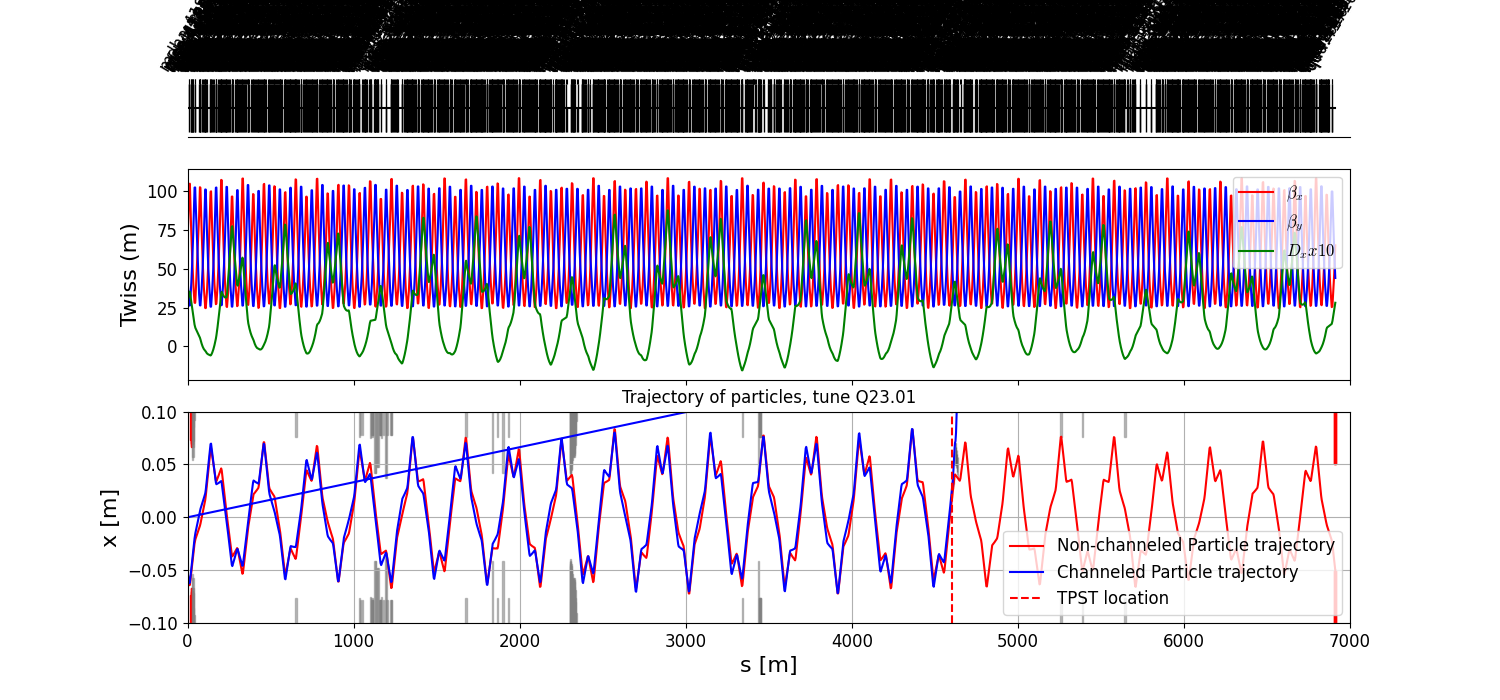

In [169]:
from functions import plot_twiss

fig = plt.figure(figsize=(15,7))

plot_twiss(fig, tw, line)

fig.axes[2].grid(True)
#fig.axes[2].set_xlim(200, 320)

fig.axes[2].plot(recordNONCH.s[0], recordNONCH.x[0], '-', color='red', label='Non-channeled Particle trajectory')
fig.axes[2].plot(recordCH.s[0], recordCH.x[0], '-', color='blue', label='Channeled Particle trajectory')
fig.axes[2].set_xlabel('s [m]')
fig.axes[2].set_ylabel('x [m]')
fig.axes[2].set_title(f'Trajectory of particles, tune Q{tune}')
fig.axes[2].grid(True)

fig.axes[2].set_ylim(-0.1, 0.1)
fig.axes[2].set_xlim(0, 7000)

for element_name in septa_names_with_apertures:
    x = line[element_name].interaction_process.blade_position
    thickness = line[element_name].interaction_process.thickness
    s = line.get_table()['s', element_name]
    fig.axes[2].add_patch(mpl.patches.Rectangle((s, x), 1, thickness, color='k', alpha=0.3))
    

# Insert rectangles for each element in df_elements
for _, row in df_elements.iterrows():
    color = 'grey'
    alpha = 0.5
    if row['Element Name'] in [elem[0] for elem in blocking_elements]:
        color = 'red'
        alpha = 1.0
    # Rectangle from min_x to bottom
    rect_min = plt.Rectangle((row['Position'], -0.25), width=8, height=row['min_x'] + 0.25, color=color, alpha=alpha)
    fig.axes[2].add_patch(rect_min)
    
    # Rectangle from max_x to top
    rect_max = plt.Rectangle((row['Position'], row['max_x']), width=8, height=0.25 - row['max_x'], color=color, alpha=alpha)
    fig.axes[2].add_patch(rect_max)

fig.axes[2].axvline(x=tpst_position, color='r', linestyle='--', label='TPST location')
fig.axes[2].legend()